In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
import umap
import re
import spacy
from wordcloud import WordCloud
import networkx as nx
from collections import Counter
import itertools

In [ ]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 67.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [21]:
nlp = spacy.load("en_core_web_sm")

In [22]:
plt.style.use('seaborn-v0_8-bright')
sns.set_palette("deep")

In [23]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    doc = nlp(text)
    tokens = [
        token.lemma_ for token in doc
        if not token.is_stop and not token.is_punct and len(token) > 2
    ]
    return ' '.join(tokens)

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
df = pd.read_json("drive/MyDrive/dataset_news.json", lines=True)
df = df[['headline']].dropna().drop_duplicates()
df['processed_headline'] = df['headline'].apply(preprocess_text)
texts = df['processed_headline'].tolist()
print(f"Loaded {len(texts)} unique, preprocessed headlines.")

Loaded 5000 unique, preprocessed headlines.


In [26]:
# Data exploration
print("\nData Exploration:")
print(f"Total headlines: {len(df)}")
print(f"Average headline length (characters): {df['headline'].str.len().mean():.2f}")
print(f"Average processed headline length (words): {df['processed_headline'].str.split().str.len().mean():.2f}")
print("\nSample headlines:")
print(df['headline'].head().to_string())


Data Exploration:
Total headlines: 5000
Average headline length (characters): 69.23
Average processed headline length (words): 7.60

Sample headlines:
0    Over 4 Million Americans Roll Up Sleeves For O...
1    American Airlines Flyer Charged, Banned For Li...
2    23 Of The Funniest Tweets About Cats And Dogs ...
3    The Funniest Tweets From Parents This Week (Se...
4    Woman Who Called Cops On Black Bird-Watcher Lo...


In [27]:
# 2. Embeddings
models = {
    'MiniLM': SentenceTransformer('all-MiniLM-L6-v2'),
    'DistilBERT': SentenceTransformer('distilbert-base-nli-mean-tokens')
}
embeddings = {name: model.encode(texts, show_progress_bar=True) for name, model in models.items()}

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

In [28]:
# 3. UMAP
reducer = umap.UMAP(n_components=2, random_state=42)
umap_embeddings = {name: reducer.fit_transform(emb) for name, emb in embeddings.items()}

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [29]:
# 4. Clustering
num_clusters = 4
clustering_algorithms = {
    'KMeans': KMeans(n_clusters=num_clusters, random_state=42),
    'Hierarchical': AgglomerativeClustering(n_clusters=num_clusters)
}
results = {}
for emb_name, emb in embeddings.items():
    results[emb_name] = {}
    for algo_name, algo in clustering_algorithms.items():
        labels = algo.fit_predict(emb)
        results[emb_name][algo_name] = {
            'labels': labels,
            'silhouette': silhouette_score(emb, labels),
            'calinski_harabasz': calinski_harabasz_score(emb, labels)
        }
        print(f"\n{algo_name} with {emb_name} — Silhouette: {results[emb_name][algo_name]['silhouette']:.4f}, Calinski-Harabasz: {results[emb_name][algo_name]['calinski_harabasz']:.2f}")


KMeans with MiniLM — Silhouette: 0.0255, Calinski-Harabasz: 110.32

Hierarchical with MiniLM — Silhouette: 0.0135, Calinski-Harabasz: 73.22

KMeans with DistilBERT — Silhouette: 0.0334, Calinski-Harabasz: 208.16

Hierarchical with DistilBERT — Silhouette: -0.0047, Calinski-Harabasz: 126.03


In [30]:
# Assign clusters
best_model = 'MiniLM'
best_algo = 'KMeans'
df['cluster'] = results[best_model][best_algo]['labels']

In [31]:
# 5. Topic Extraction
def get_top_words(texts, n=10):
    vectorizer = TfidfVectorizer(stop_words='english', max_features=10000)
    X = vectorizer.fit_transform(texts)
    indices = np.argsort(vectorizer.idf_)[::-1]
    features = vectorizer.get_feature_names_out()
    return [features[i] for i in indices[:n]]

cluster_top_words = {
    cluster_num: get_top_words(df[df['cluster'] == cluster_num]['processed_headline'].tolist())
    for cluster_num in range(num_clusters)
}

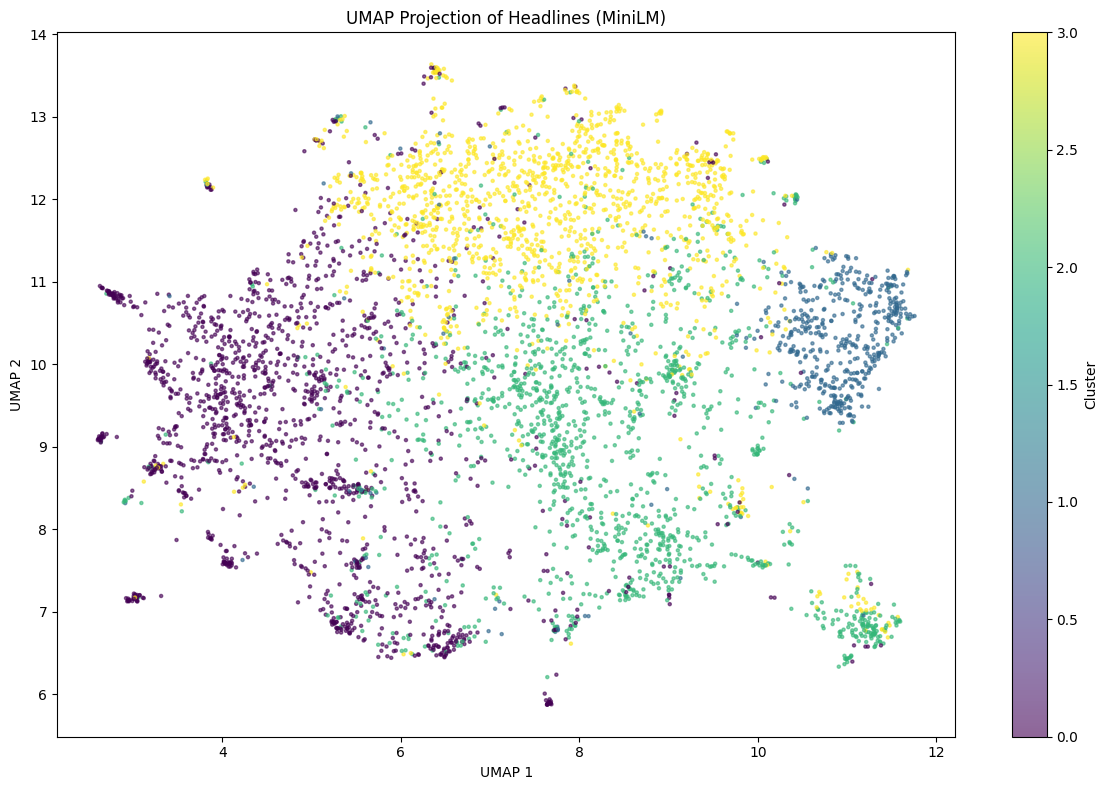

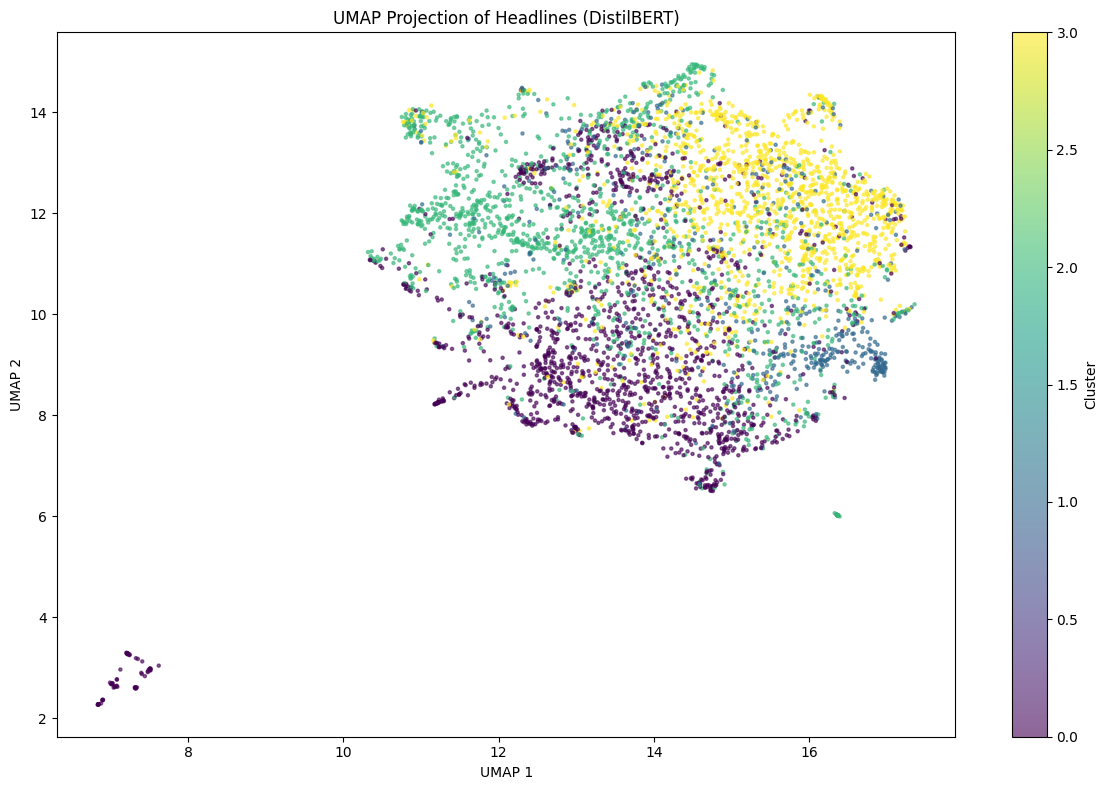

In [32]:
# 6. Visualizations
# Cluster Plot
for name, emb in umap_embeddings.items():
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(emb[:, 0], emb[:, 1], c=df['cluster'], cmap='viridis', s=5, alpha=0.6)
    plt.title(f'UMAP Projection of Headlines ({name})')
    plt.colorbar(scatter, label='Cluster')
    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.tight_layout()
    plt.show()

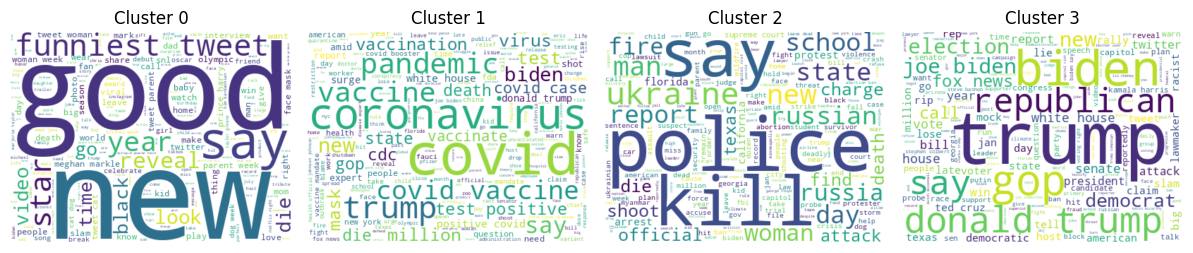

In [33]:
# Word Clouds
plt.figure(figsize=(15, 10))
for cluster_num in range(num_clusters):
    plt.subplot(2, 5, cluster_num + 1)
    words = ' '.join(df[df['cluster'] == cluster_num]['processed_headline'])
    wordcloud = WordCloud(width=400, height=300, background_color='white').generate(words)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Cluster {cluster_num}')
    plt.axis('off')
plt.tight_layout()
plt.show()

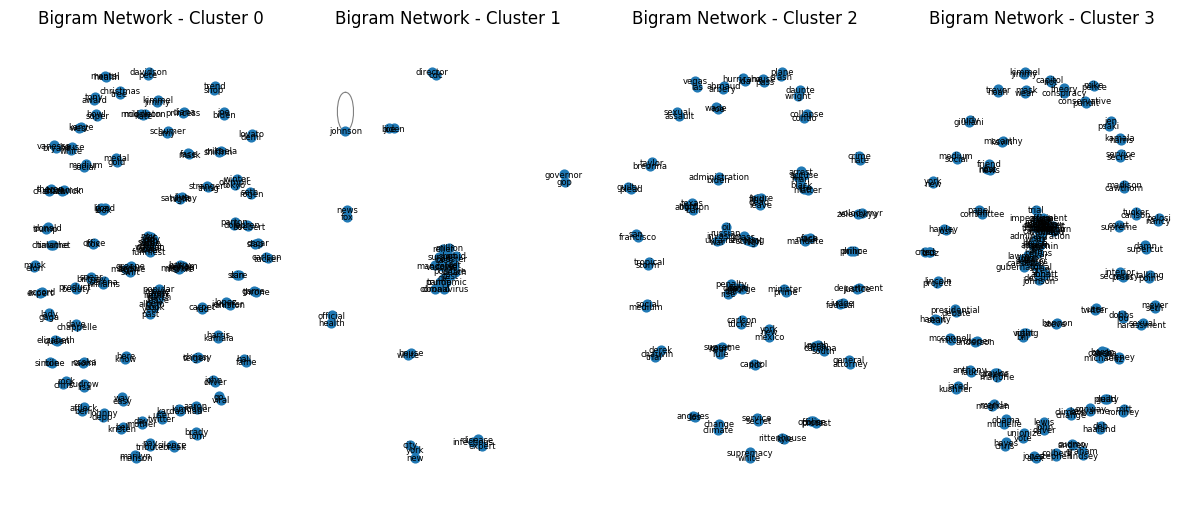

In [40]:
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter

def create_bigram_graph(texts, min_count=3):
    """Create a NetworkX graph of frequent adjacent bigrams."""
    words = ' '.join(texts).split()
    bigrams = [(words[i], words[i + 1]) for i in range(len(words) - 1)]
    bigram_counts = Counter(bigrams)

    G = nx.Graph()
    for bigram, count in bigram_counts.items():
        if count > min_count:
            G.add_edge(bigram[0], bigram[1], weight=count)
    return G

# Plot bigram networks for each cluster
plt.figure(figsize=(15, 10))
for cluster_num in range(num_clusters):
    plt.subplot(2, 5, cluster_num + 1)
    cluster_texts = df[df['cluster'] == cluster_num]['processed_headline'].tolist()
    G = create_bigram_graph(cluster_texts, min_count=3)

    pos = nx.spring_layout(G, seed=42)
    nx.draw(
        G,
        pos,
        node_size=40,
        font_size=6,
        with_labels=True,
        edge_color='gray',
        width=[G[u][v]['weight'] * 0.2 for u, v in G.edges()]  # Optional: scale edge width by weight
    )
    plt.title(f'Bigram Network - Cluster {cluster_num}')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [35]:
# 7. Topic Prediction
def predict_topic(sentence, model_name='MiniLM', algo_name='KMeans'):
    processed = preprocess_text(sentence)
    embedding = models[model_name].encode([processed])
    cluster = clustering_algorithms[algo_name].fit_predict(embeddings[model_name])[-1]
    nn = NearestNeighbors(n_neighbors=5).fit(embeddings[model_name])
    distances, indices = nn.kneighbors(embedding)
    print(f"\nInput sentence: '{sentence}'")
    print("Most similar:")
    for i, idx in enumerate(indices[0]):
        print(f"{i+1}. ({df['cluster'].iloc[idx]}) [{distances[0][i]:.3f}] - {df['headline'].iloc[idx]}")
    print(f"=> Predicted cluster: {cluster}")
    print(f"   Keywords: {cluster_top_words[cluster]}")
    return cluster

In [36]:
# 8. Results Summary
print("\nPerformance Metrics:")
for emb_name in results:
    print(f"\n{emb_name} Embeddings:")
    for algo_name in results[emb_name]:
        print(f"  {algo_name} - Silhouette: {results[emb_name][algo_name]['silhouette']:.4f}, CH: {results[emb_name][algo_name]['calinski_harabasz']:.2f}")


Performance Metrics:

MiniLM Embeddings:
  KMeans - Silhouette: 0.0255, CH: 110.32
  Hierarchical - Silhouette: 0.0135, CH: 73.22

DistilBERT Embeddings:
  KMeans - Silhouette: 0.0334, CH: 208.16
  Hierarchical - Silhouette: -0.0047, CH: 126.03


In [37]:
# 9. Example Predictions
test_sentences = [
    "NASA prepares new Mars rover launch",
    "Taylor Swift announces world tour dates",
    "Stock market experiences unexpected crash",
    "President signs new climate bill into law"
]
for sentence in test_sentences:
    predict_topic(sentence)


Input sentence: 'NASA prepares new Mars rover launch'
Most similar:
1. (0) [1.152] - SpaceX Capsule And NASA Astronauts Make First Splashdown In 45 Years
2. (2) [1.152] - 'Safety Is Always First': NASA Reschedules Artemis Moon Mission To Saturday
3. (2) [1.154] - Fuel Leak Ruins NASA's 2nd Shot At Launching New Moon Rocket
4. (2) [1.160] - No Life On Martian Meteorite Found In Antarctica In 1996
5. (2) [1.171] - Parachute For Mars Rover Mars Contains A Secret Message
=> Predicted cluster: 1
   Keywords: ['aaron', 'zoom', 'allegation', 'alexia', 'alexandria', 'alex', 'alaska', 'alarm', 'airport', 'airhead']

Input sentence: 'Taylor Swift announces world tour dates'
Most similar:
1. (0) [0.905] - And The Award For Most Enthusiastic VMAs Guest Goes To Taylor Swift
2. (0) [0.984] - Blake Lively Is Making Her Directorial Debut With Taylor Swift's New Music Video
3. (0) [0.987] - Yes, Taylor Swift Writes Her Own Songs
4. (0) [1.003] - Taylor Swift Teams Up With Ryan Reynolds To Debut New Ve

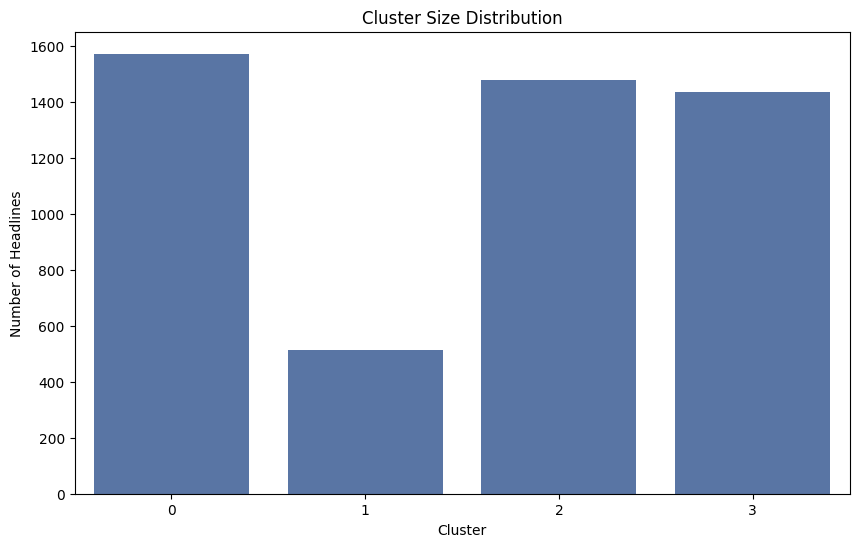

In [38]:
# 10. Cluster Distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='cluster', data=df)
plt.title('Cluster Size Distribution')
plt.xlabel('Cluster')
plt.ylabel('Number of Headlines')
plt.show()

In [39]:
# 11. Keywords
print("\nTop Words per Cluster:")
for cluster_num, words in cluster_top_words.items():
    print(f"Cluster {cluster_num}: {', '.join(words)}")


Top Words per Cluster:
Cluster 0: ad, activism, action, admission, admirer, addition, advocacy, adulthood, adult, adorably
Cluster 1: aaron, zoom, allegation, alexia, alexandria, alex, alaska, alarm, airport, airhead
Cluster 2: aap, zoom, zookeeper, abbott, abductee, zip, zillow, zerotolerance, zero, abdulrauf
Cluster 3: abandon, zuckerberg, zoom, zoe, zings, zero, abby, ability, youngkin, abject
